#  HR Text Analysis — NLP & Sentiment Analysis Pipeline

**Dataset** : `HRDataset_v14_enriched.csv`  
**Objectif** : Identifier les facteurs de démission en analysant les textes RH (feedbacks d'entretien de sortie, demandes de transfert) et prédire quels employés sont à risque de quitter l'entreprise.


##  Installation des dépendances
```bash
pip install pandas scikit-learn matplotlib seaborn
```

In [ ]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.family": "DejaVu Sans"})

COLORS = {
    "positive": "#2ecc71",
    "negative": "#e74c3c",
    "neutral":  "#95a5a6",
    "primary":  "#2c3e50",
    "accent":   "#3498db",
}

print("Librairies chargées avec succès")

✅ Librairies chargées avec succès


---
##  BLOC 1 — Chargement & Exploration des données textuelles

###  Contexte

Le dataset contient **311 employés** et deux colonnes de texte simulé :

- **`ExitInterview_Feedback`** : pour les employés partis: extrait d'entretien de sortie aligné sur la raison de départ (`TermReason`) ; pour les actifs: commentaire d'enquête de satisfaction aligné sur les scores `EmpSatisfaction` et `EngagementSurvey`.
- **`InternalTransferRequest`** : demande formelle de mobilité interne (présente pour ~40% des actifs et ~30% des démissionnaires volontaires).

>  **Pourquoi du texte simulé ?** En contexte pédagogique, les vrais entretiens RH sont confidentiels. Les textes générés ici reproduisent les patterns linguistiques réels qu'on trouverait dans un vrai dataset.

In [47]:
# Chargement du dataset enrichi
df = pd.read_csv("HRDataset_v14_enriched.csv", encoding="utf-8-sig")

# Colonnes textuelles et cible
TEXT_FEEDBACK = "ExitInterview_Feedback"
TEXT_TRANSFER = "InternalTransferRequest"
TARGET_COL    = "EmploymentStatus"

# Cible binaire : 1 = a quitté, 0 = encore en poste
df["Attrition"] = df[TARGET_COL].apply(
    lambda x: 1 if x in ("Voluntarily Terminated", "Terminated for Cause") else 0
)

# Nettoyage des NaN
df[TEXT_FEEDBACK] = df[TEXT_FEEDBACK].fillna("")
df[TEXT_TRANSFER] = df[TEXT_TRANSFER].fillna("")

print(f"Dimensions du dataset : {df.shape}")
df[["Employee_Name", "EmploymentStatus", "TermReason", "EmpSatisfaction", "ExitInterview_Feedback"]].head(4)

Dimensions du dataset : (311, 39)


,Employee_Name,EmploymentStatus,TermReason,EmpSatisfaction,ExitInterview_Feedback
0,"Adinolfi, Wilson K",Active,N/A-StillEmployed,5,Adinolfi shared positive feedback about the te...
1,"Ait Sidi, Karthikeyan",Voluntarily Terminated,career change,3,"During the interview, Ait Sidi explained that ..."
2,"Akinkuolie, Sarah",Voluntarily Terminated,hours,3,Akinkuolie noted that sustained periods of ove...
3,"Alagbe,Trina",Active,N/A-StillEmployed,5,Alagbe shared positive feedback about the team...


In [25]:
# Statistiques descriptives sur les textes
stats = pd.DataFrame({
    "Colonne": [TEXT_FEEDBACK, TEXT_TRANSFER],
    "Remplie (n)": [
        (df[TEXT_FEEDBACK] != "").sum(),
        (df[TEXT_TRANSFER] != "").sum(),
    ],
    "Longueur moyenne (car.)": [
        df[df[TEXT_FEEDBACK] != ""][TEXT_FEEDBACK].str.len().mean().round(0),
        df[df[TEXT_TRANSFER] != ""][TEXT_TRANSFER].str.len().mean().round(0),
    ],
    "Longueur max (car.)": [
        df[TEXT_FEEDBACK].str.len().max(),
        df[TEXT_TRANSFER].str.len().max(),
    ],
})
print(stats.to_string(index=False))

                Colonne  Remplie (n)  Longueur moyenne (car.)  Longueur max (car.)
 ExitInterview_Feedback          311                    276.0                  345
InternalTransferRequest           46                    438.0                  501


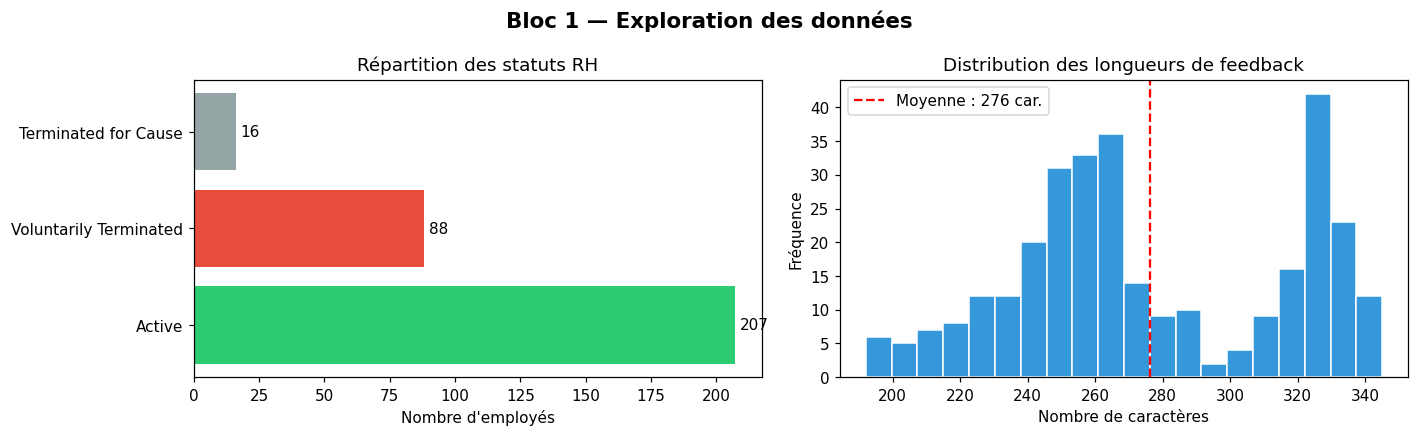

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Bloc 1 — Exploration des données", fontsize=14, fontweight="bold")

# Répartition des statuts
counts = df[TARGET_COL].value_counts()
axes[0].barh(counts.index, counts.values,
             color=[COLORS["positive"], COLORS["negative"], COLORS["neutral"]])
axes[0].set_title("Répartition des statuts RH")
axes[0].set_xlabel("Nombre d'employés")
for i, v in enumerate(counts.values):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=10)

# Distribution des longueurs de feedback
lengths = df[df[TEXT_FEEDBACK] != ""][TEXT_FEEDBACK].str.len()
axes[1].hist(lengths, bins=20, color=COLORS["accent"], edgecolor="white")
axes[1].axvline(lengths.mean(), color="red", linestyle="--", label=f"Moyenne : {lengths.mean():.0f} car.")
axes[1].set_title("Distribution des longueurs de feedback")
axes[1].set_xlabel("Nombre de caractères")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.tight_layout()
plt.show()

---
##  BLOC 2 — Approche 1 : Analyse de sentiment lexicale (règles)

###  Principe

L'approche la plus simple : on construit deux **lexiques** de mots positifs et négatifs, puis pour chaque texte on calcule :

$$\text{score} = \frac{\#\text{mots positifs} - \#\text{mots négatifs}}{\#\text{mots total}}$$

| Score | Label |
|-------|-------|
| > +0.02 |  **positive** |
| < -0.02 |  **negative** |
| entre les deux |  **neutral** |

On gère aussi la **négation simple** : si un mot positif est précédé de *"not"*, *"no"*, *"never"*... il compte comme négatif.

** Avantages** : transparent, rapide, aucun entraînement, explicable mot par mot  
** Limites** : pas de contexte profond, sensible à l'ironie, dépend de la qualité du lexique

>  **Responsible AI** : Cette méthode est **entièrement interprétable** — on peut montrer exactement quels mots ont contribué au score de chaque employé.

In [50]:
# ── Lexiques ────────────────────────────────────────────────────────────────
POSITIVE_WORDS = {
    "positive", "appreciated", "valued", "satisfied", "happy", "proud",
    "collaborative", "supportive", "excellent", "strong", "growth",
    "recognition", "flexibility", "transparent", "engaged", "rewarding",
    "commended", "praised", "achievement", "alignment", "trust",
    "motivated", "welcoming", "enthusiastic", "warmly", "succeed",
    "opportunity", "benefited", "smooth", "genuine", "constructive",
    "effective", "open", "balance", "healthy",
}

NEGATIVE_WORDS = {
    "dissatisfied", "unhappy", "frustrated", "micromanaged", "overworked",
    "stagnant", "ignored", "unclear", "punitive", "conflict", "tense",
    "exhausted", "unresolved", "fear", "reprisal", "low", "broken",
    "negative", "concern", "complaint", "disappointment", "inadequate",
    "poorly", "misaligned", "leaving", "resigned", "resignation",
    "terminated", "departure", "lack", "unable", "untenable",
    "demotivating", "deterioration", "incompatible", "reluctantly",
    "disconnect", "opaque", "chronic",
}

NEGATION_WORDS = {"not", "no", "never", "without", "lack", "barely", "hardly"}

print(f"Lexique positif : {len(POSITIVE_WORDS)} mots")
print(f"Lexique négatif : {len(NEGATIVE_WORDS)} mots")

Lexique positif : 35 mots
Lexique négatif : 39 mots


In [51]:
def tokenize(text: str) -> list:
    """Nettoyage basique : minuscules, suppression ponctuation."""
    return re.findall(r"\b[a-z]+\b", text.lower())


def lexical_sentiment(text: str, threshold: float = 0.02) -> dict:
    """
    Calcule le score de sentiment d'un texte.
    Gère la négation simple (fenêtre de 2 mots avant le mot évalué).
    
    Retourne : score, label, mots positifs et négatifs détectés.
    """
    if not text.strip():
        return {"score": 0.0, "label": "neutral", "pos_words": [], "neg_words": []}

    tokens = tokenize(text)
    n = len(tokens)
    if n == 0:
        return {"score": 0.0, "label": "neutral", "pos_words": [], "neg_words": []}

    pos_score, neg_score = 0, 0
    found_pos, found_neg = [], []

    for i, token in enumerate(tokens):
        # Fenêtre de négation : les 2 tokens précédents
        context = tokens[max(0, i - 2): i]
        negated = any(w in NEGATION_WORDS for w in context)

        if token in POSITIVE_WORDS:
            if negated:
                neg_score += 1
                found_neg.append(f"not_{token}")
            else:
                pos_score += 1
                found_pos.append(token)
        elif token in NEGATIVE_WORDS:
            if negated:
                pos_score += 1
                found_pos.append(f"not_{token}")
            else:
                neg_score += 1
                found_neg.append(token)

    score = (pos_score - neg_score) / n
    label = "positive" if score > threshold else ("negative" if score < -threshold else "neutral")

    return {"score": round(score, 4), "label": label,
            "pos_words": found_pos, "neg_words": found_neg}


# ── Application sur tout le dataset ─────────────────────────────────────────
results = df[TEXT_FEEDBACK].apply(lexical_sentiment)
df["sentiment_score"] = results.apply(lambda x: x["score"])
df["sentiment_label"] = results.apply(lambda x: x["label"])

# Résumé
dist = df["sentiment_label"].value_counts()
print("Distribution des sentiments :")
for label, count in dist.items():
    bar = "█" * int(count / 3)
    print(f"  {label:<12} : {count:>4} ({count/len(df)*100:.1f}%)  {bar}")

Distribution des sentiments :
  positive     :  144 (46.3%)  ████████████████████████████████████████████████
  neutral      :  129 (41.5%)  ███████████████████████████████████████████
  negative     :   38 (12.2%)  ████████████


In [52]:
# ── Exemple d'explication individuelle ──────────────────────────────────────
print(" Exemple d'interprétation individuelle\n")

# Choisir un employé négatif
neg_idx = df[df["sentiment_label"] == "negative"].index[0]
ex = results.iloc[neg_idx]

print(f"Employé    : {df['Employee_Name'].iloc[neg_idx]}")
print(f"Statut     : {df[TARGET_COL].iloc[neg_idx]}")
print(f"Feedback   : {df[TEXT_FEEDBACK].iloc[neg_idx][:200]}...")
print(f"\nScore      : {ex['score']}")
print(f"Label      : {ex['label']}")
print(f"Mots (+)   : {ex['pos_words']}")
print(f"Mots (-)   : {ex['neg_words']}")

 Exemple d'interprétation individuelle

Employé    : Ait Sidi, Karthikeyan   
Statut     : Voluntarily Terminated
Feedback   : During the interview, Ait Sidi explained that after several years in the IT/IS department, they felt ready for a fundamentally different challenge. They spoke positively about their colleagues but ind...

Score      : -0.0244
Label      : negative
Mots (+)   : []
Mots (-)   : ['misaligned']


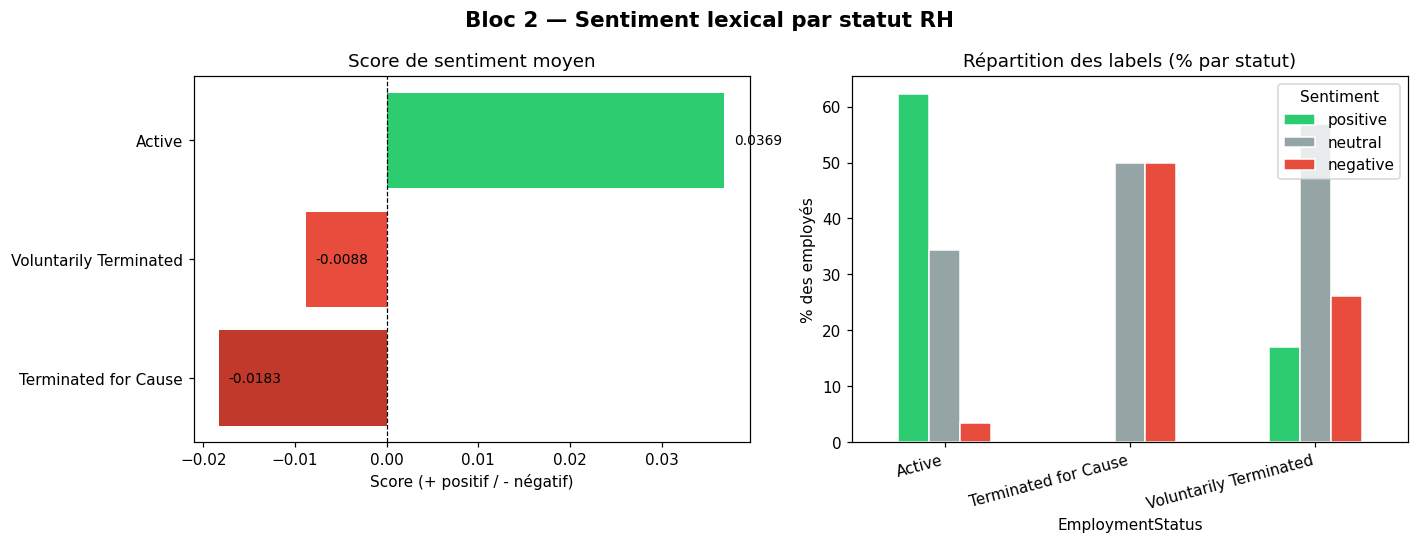

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Bloc 2 — Sentiment lexical par statut RH", fontsize=14, fontweight="bold")

# Score moyen par statut
means = df.groupby(TARGET_COL)["sentiment_score"].mean().sort_values()
palette = {
    "Active": COLORS["positive"],
    "Voluntarily Terminated": COLORS["negative"],
    "Terminated for Cause": "#c0392b",
}
colors = [palette.get(s, COLORS["neutral"]) for s in means.index]
bars = axes[0].barh(means.index, means.values, color=colors)
axes[0].set_title("Score de sentiment moyen")
axes[0].set_xlabel("Score (+ positif / - négatif)")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, means.values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)

# Répartition labels par statut
ct = pd.crosstab(df[TARGET_COL], df["sentiment_label"], normalize="index") * 100
for col in ["positive", "neutral", "negative"]:
    if col not in ct.columns:
        ct[col] = 0
ct = ct[["positive", "neutral", "negative"]]
ct.plot(kind="bar", ax=axes[1],
        color=[COLORS["positive"], COLORS["neutral"], COLORS["negative"]],
        edgecolor="white")
axes[1].set_title("Répartition des labels (% par statut)")
axes[1].set_ylabel("% des employés")
axes[1].set_xticklabels(ct.index, rotation=15, ha="right")
axes[1].legend(title="Sentiment")

plt.tight_layout()
plt.show()

---
##  BLOC 3 — Approche 2 : Classification ML (TF-IDF + Régression Logistique)

###  Principe

#### TF-IDF (Term Frequency – Inverse Document Frequency)
On transforme chaque texte en **vecteur numérique** : chaque dimension correspond à un mot du vocabulaire, et sa valeur reflète son importance relative dans le document.

$$\text{TF-IDF}(t, d) = \underbrace{\frac{f_{t,d}}{|d|}}_{\text{fréquence locale}} \times \underbrace{\log\frac{N}{n_t}}_{\text{rareté globale}}$$

→ *"resignation"* pèse plus que *"the"* car il est rare dans l'ensemble des documents.

#### Régression Logistique
Modèle linéaire supervisé : il apprend à partir des textes étiquetés (actif / parti) quels mots sont les meilleurs prédicteurs. Les **coefficients = importance de chaque mot**.

** Avantages** : interprétable, rapide, bon baseline  
** Limites** : ignore l'ordre des mots, pas de sémantique profonde

>  **Responsible AI** : On utilise la **validation croisée** (5 folds) pour éviter le surapprentissage. On vérifie que le modèle ne s'appuie pas sur des proxies démographiques.

In [54]:
# Préparation des données
mask = df[TEXT_FEEDBACK].str.len() > 20
X_text = df.loc[mask, TEXT_FEEDBACK]
y      = df.loc[mask, "Attrition"]

print(f"Échantillon : {len(X_text)} textes")
print(f"  Classe 0 (actif)   : {(y == 0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Classe 1 (parti)   : {(y == 1).sum()} ({(y==1).mean()*100:.1f}%)")

# Pipeline TF-IDF → Régression Logistique
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=500,        # 500 mots les plus informatifs
        ngram_range=(1, 2),      # unigrammes + bigrammes
        stop_words="english",
        min_df=2,                # mot présent dans ≥ 2 documents
        sublinear_tf=True,       # atténuation log des fréquences
    )),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight="balanced", # compense le déséquilibre des classes
        max_iter=1000,
        random_state=42,
    )),
])

# Validation croisée (5 folds)
cv_scores = cross_val_score(pipeline, X_text, y, cv=5, scoring="f1", n_jobs=-1)
print(f"\nValidation croisée F1 (5 folds) :")
print(f"  Scores  : {[round(s, 3) for s in cv_scores]}")
print(f"  Moyenne : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Échantillon : 311 textes
  Classe 0 (actif)   : 207 (66.6%)
  Classe 1 (parti)   : 104 (33.4%)

Validation croisée F1 (5 folds) :
  Scores  : [np.float64(0.955), np.float64(0.93), np.float64(1.0), np.float64(1.0), np.float64(0.977)]
  Moyenne : 0.972 ± 0.027


In [55]:
# Entraînement final + évaluation sur test set
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Rapport de classification (test set — {len(y_test)} exemples) :\n")
print(classification_report(y_test, y_pred, target_names=["Actif", "A quitté"]))

Rapport de classification (test set — 63 exemples) :

              precision    recall  f1-score   support

       Actif       1.00      0.95      0.98        42
    A quitté       0.91      1.00      0.95        21

    accuracy                           0.97        63
   macro avg       0.96      0.98      0.97        63
weighted avg       0.97      0.97      0.97        63



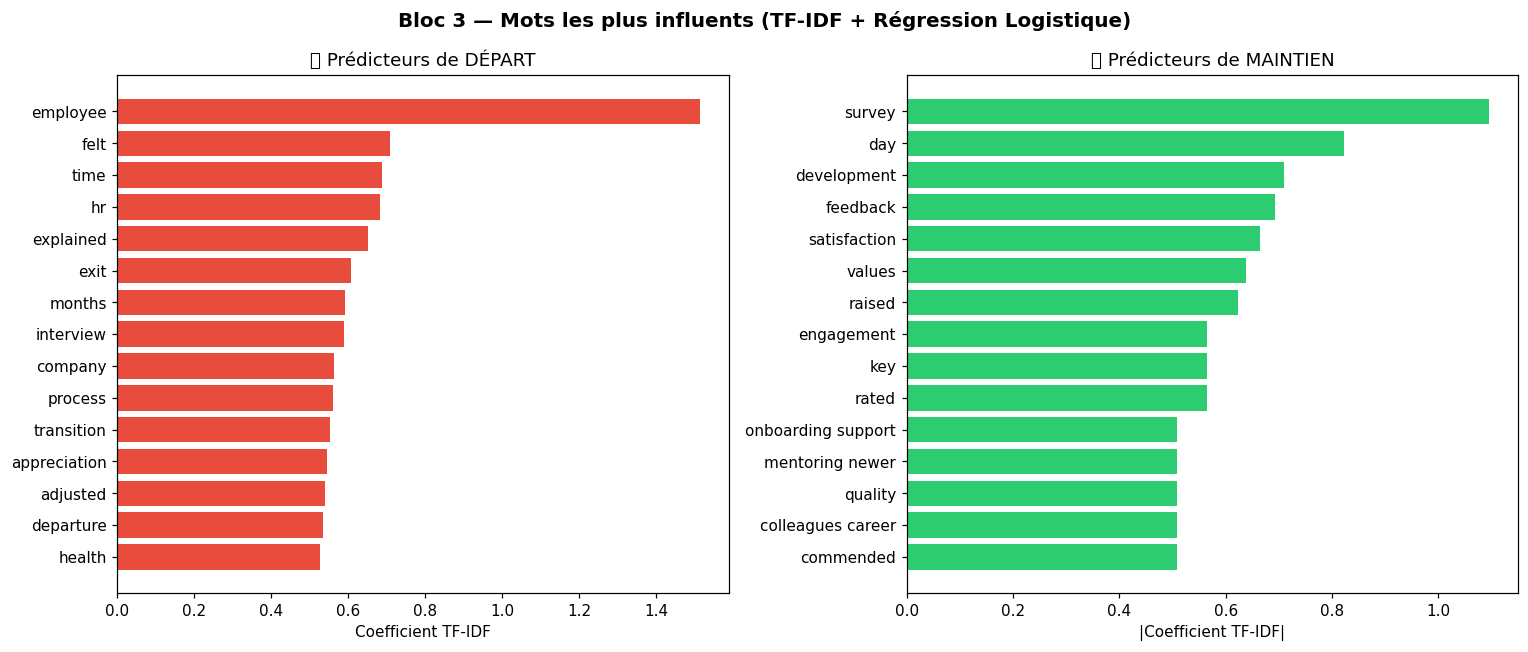

In [56]:
# Mots les plus influents par classe
vocab = pipeline.named_steps["tfidf"].get_feature_names_out()
coef  = pipeline.named_steps["clf"].coef_[0]
top_n = 15

idx_depart  = np.argsort(coef)[-top_n:][::-1]
idx_maintien = np.argsort(coef)[:top_n]

words_depart  = [(vocab[i], coef[i]) for i in idx_depart]
words_maintien = [(vocab[i], abs(coef[i])) for i in idx_maintien]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Bloc 3 — Mots les plus influents (TF-IDF + Régression Logistique)",
             fontsize=13, fontweight="bold")

w_dep = [w for w, _ in words_depart]
c_dep = [c for _, c in words_depart]
axes[0].barh(w_dep[::-1], c_dep[::-1], color=COLORS["negative"])
axes[0].set_title("🔴 Prédicteurs de DÉPART")
axes[0].set_xlabel("Coefficient TF-IDF")

w_mai = [w for w, _ in words_maintien]
c_mai = [c for _, c in words_maintien]
axes[1].barh(w_mai[::-1], c_mai[::-1], color=COLORS["positive"])
axes[1].set_title("🟢 Prédicteurs de MAINTIEN")
axes[1].set_xlabel("|Coefficient TF-IDF|")

plt.tight_layout()
plt.show()

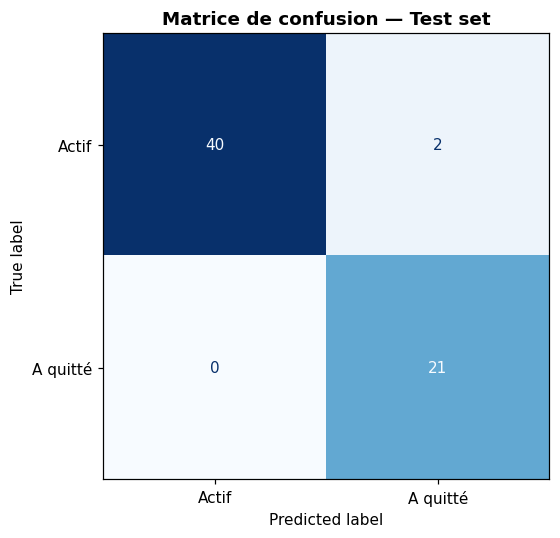


📌 Lecture de la matrice :
  Ligne = réalité | Colonne = prédiction du modèle
  Faux négatifs (a quitté prédit actif)  : 0 — risque de ne pas alerter un RH
  Faux positifs (actif prédit parti)      : 2 — risque de stresser inutilement un RH


In [ ]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Actif", "A quitté"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matrice de confusion — Test set", fontweight="bold")
plt.tight_layout()
plt.show()

print("\n Lecture de la matrice :")
print("  Ligne = réalité | Colonne = prédiction du modèle")
print(f"  Faux négatifs (a quitté prédit actif)  : {cm[1][0]} — risque de ne pas alerter un RH")
print(f"  Faux positifs (actif prédit parti)      : {cm[0][1]} — risque de stresser inutilement un RH")

---
## BLOC 4 — Approche 3 : Extraction de thèmes (TF-IDF + K-Means)

###  Principe

Contrairement au Bloc 3 (supervisé), ici on ne connaît pas les labels à l'avance. On laisse l'algorithme **découvrir des groupes** de textes similaires.

**Étapes :**
1. TF-IDF → vecteurs de haute dimension (500 dimensions)
2. **LSA** (Latent Semantic Analysis = TruncatedSVD) → réduction à 50 dimensions en préservant les relations sémantiques entre mots
3. **K-Means** → regroupement en K clusters selon la similarité cosinus
4. **SVD 2D** → projection pour visualisation

>  **Responsible AI** : Les clusters sont des **groupes de textes, pas de personnes**. Chaque thème doit être interprété par un RH — l'algorithme suggère, l'humain décide.

In [57]:
K = 5  # Nombre de thèmes

# Vectorisation + réduction LSA
tfidf_topics = TfidfVectorizer(
    max_features=300, ngram_range=(1, 2),
    stop_words="english", min_df=2, sublinear_tf=True
)
mask2 = df[TEXT_FEEDBACK].str.len() > 20
X_all = df.loc[mask2, TEXT_FEEDBACK]
X_tfidf = tfidf_topics.fit_transform(X_all)

svd = TruncatedSVD(n_components=50, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)

# Clustering K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_lsa)

df_topics = df.loc[mask2].copy()
df_topics["topic"] = clusters
df["topic"] = np.nan
df.loc[mask2, "topic"] = clusters

# Top mots par thème
vocab_t = tfidf_topics.get_feature_names_out()
centroids = kmeans.cluster_centers_ @ svd.components_

print(f"{K} thèmes identifiés dans les feedbacks :\n")
for k in range(K):
    top_idx   = np.argsort(centroids[k])[-8:][::-1]
    top_words = [vocab_t[i] for i in top_idx]
    n_in_cluster = (clusters == k).sum()
    print(f"  Thème {k} ({n_in_cluster} textes) : {', '.join(top_words)}")

5 thèmes identifiés dans les feedbacks :

  Thème 0 (35 textes) : day, coming review, committed, committed role, coming, team equitable, cycle, day day
  Thème 1 (35 textes) : support received, commended, commended quality, colleagues career, positive feedback, onboarding support, onboarding, newer colleagues
  Thème 2 (36 textes) : clearly, clearly communicated, communicated welcome, reasonably, reasonably settled, feedback development, feels, seek
  Thème 3 (38 textes) : career progression, suggested regular, suggested, survey response, concerns limited, sessions, sessions management, progression
  Thème 4 (167 textes) : employee, company, expressed, felt, team, production, described, personal


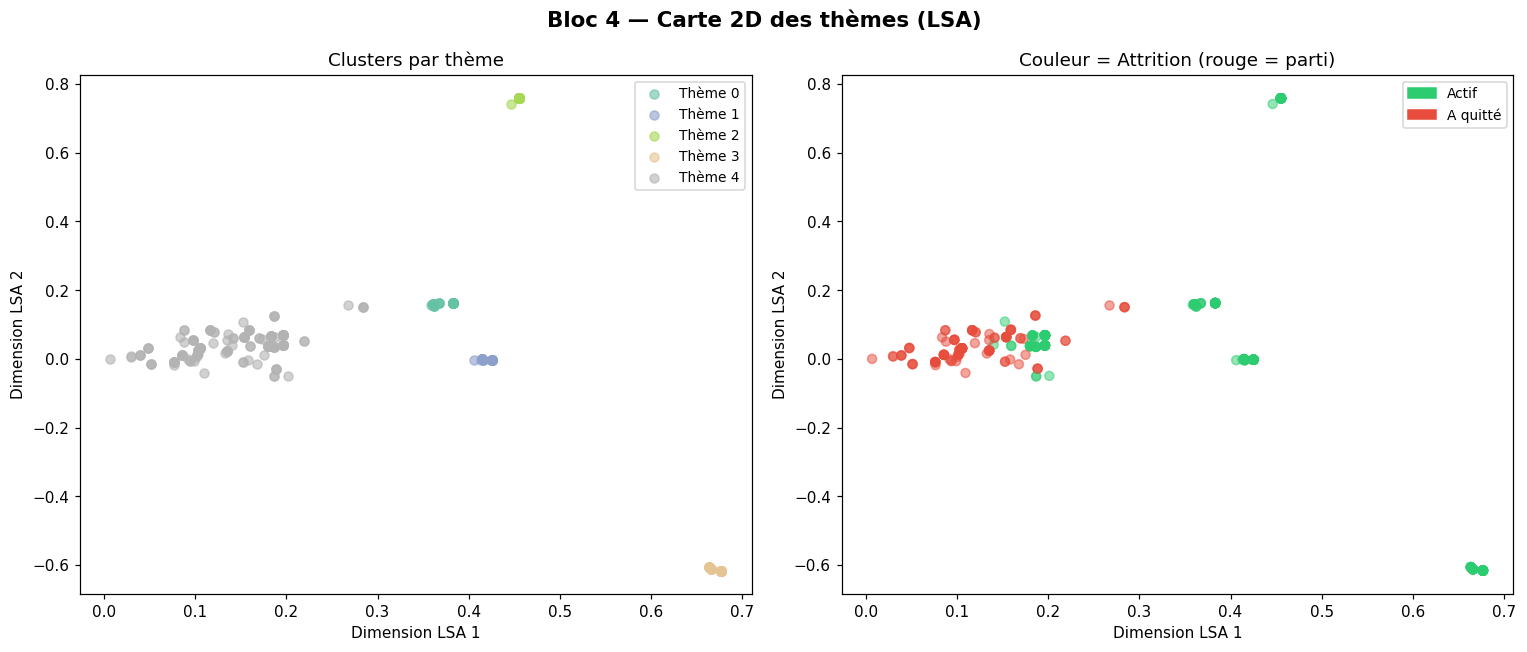

In [58]:
# Projection 2D pour visualisation
svd2d = TruncatedSVD(n_components=2, random_state=42)
X_2d  = svd2d.fit_transform(X_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Bloc 4 — Carte 2D des thèmes (LSA)", fontsize=14, fontweight="bold")

# Par thème
palette = plt.cm.Set2(np.linspace(0, 1, K))
for k in range(K):
    m = clusters == k
    axes[0].scatter(X_2d[m, 0], X_2d[m, 1], c=[palette[k]], label=f"Thème {k}", alpha=0.6, s=35)
axes[0].set_title("Clusters par thème")
axes[0].legend(fontsize=9)
axes[0].set_xlabel("Dimension LSA 1")
axes[0].set_ylabel("Dimension LSA 2")

# Par attrition
att_vals = df_topics["Attrition"].values
c_att = [COLORS["negative"] if a else COLORS["positive"] for a in att_vals]
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=c_att, alpha=0.5, s=35)
axes[1].set_title("Couleur = Attrition (rouge = parti)")
axes[1].set_xlabel("Dimension LSA 1")
axes[1].set_ylabel("Dimension LSA 2")
axes[1].legend(handles=[
    mpatches.Patch(color=COLORS["positive"], label="Actif"),
    mpatches.Patch(color=COLORS["negative"], label="A quitté"),
], fontsize=9)

plt.tight_layout()
plt.show()

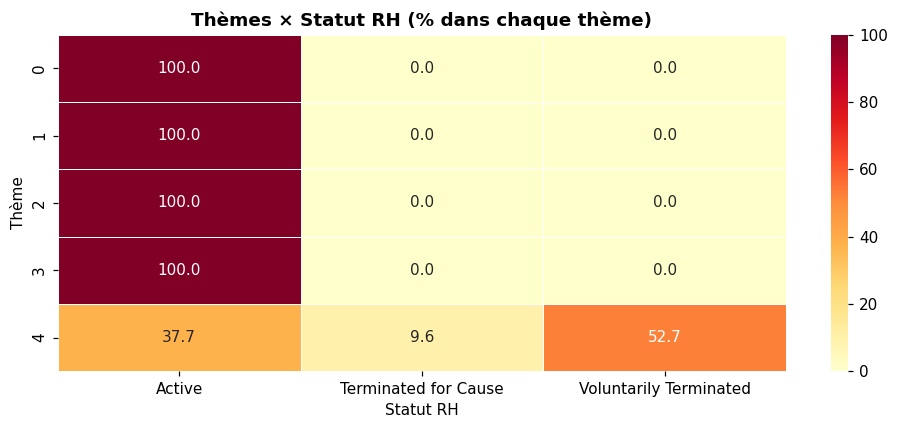


📌 Interprétation : un thème avec une forte proportion 'Voluntarily Terminated'
   correspond à un profil linguistique associé aux départs volontaires.


In [ ]:
# Heatmap : thèmes × statut
ct_topics = pd.crosstab(
    df_topics["topic"], df_topics[TARGET_COL], normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(ct_topics, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("Thèmes × Statut RH (% dans chaque thème)", fontweight="bold")
ax.set_xlabel("Statut RH")
ax.set_ylabel("Thème")
plt.tight_layout()
plt.show()

print("\n Interprétation : un thème avec une forte proportion 'Voluntarily Terminated'")
print("   correspond à un profil linguistique associé aux départs volontaires.")

---
##  BLOC 5 — Croisement NLP × Données structurées & Score de risque

###  Principe

On enrichit les résultats NLP avec les variables numériques du dataset pour une vue **360°** de chaque employé.

**Score de risque combiné :**

$$\text{risk\_score} = -\text{sentiment\_score} \times 10 + (5 - \text{EmpSatisfaction}) + (5 - \text{EngagementSurvey}) + \text{Absences} \times 0.1$$

>  **Responsible AI** : Ce score est un **signal d'alerte**, pas une sentence. Il doit déclencher une conversation RH, jamais une décision automatique (promotion bloquée, licenciement préventif, etc.).

In [59]:
# Corrélations entre score NLP et variables numériques
corr_cols = ["sentiment_score", "EmpSatisfaction", "EngagementSurvey",
             "Attrition", "Salary", "Absences", "DaysLateLast30"]
corr_data = df[corr_cols].dropna()

print("Corrélations avec le score de sentiment NLP :\n")
corr = corr_data.corr()["sentiment_score"].drop("sentiment_score").sort_values()
for var, val in corr.items():
    bar = "█" * int(abs(val) * 20)
    sign = "+" if val > 0 else "-"
    print(f"  {var:<25} : {val:+.3f}  {sign}{bar}")

Corrélations avec le score de sentiment NLP :

  Attrition                 : -0.492  -█████████
  DaysLateLast30            : -0.209  -████
  Absences                  : -0.026  -
  Salary                    : +0.017  +
  EngagementSurvey          : +0.298  +█████
  EmpSatisfaction           : +0.419  +████████


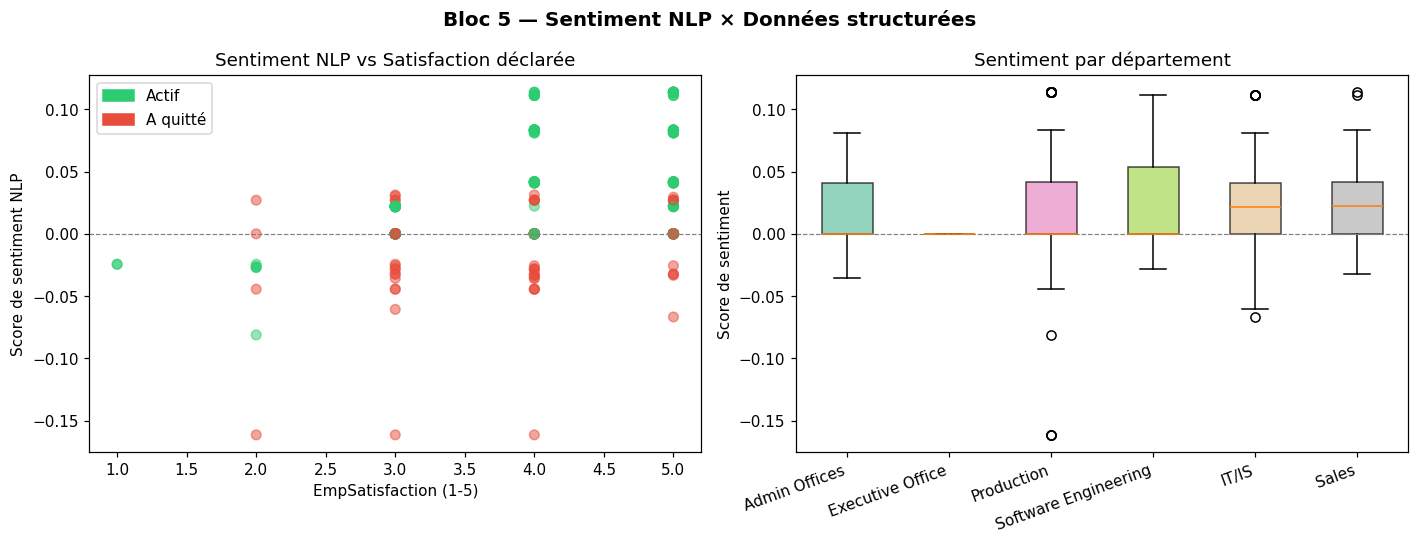

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Bloc 5 — Sentiment NLP × Données structurées", fontsize=13, fontweight="bold")

# Scatter : sentiment vs satisfaction
colors_s = [COLORS["negative"] if a else COLORS["positive"] for a in corr_data["Attrition"]]
axes[0].scatter(corr_data["EmpSatisfaction"], corr_data["sentiment_score"],
                c=colors_s, alpha=0.5, s=40)
axes[0].set_xlabel("EmpSatisfaction (1-5)")
axes[0].set_ylabel("Score de sentiment NLP")
axes[0].set_title("Sentiment NLP vs Satisfaction déclarée")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].legend(handles=[
    mpatches.Patch(color=COLORS["positive"], label="Actif"),
    mpatches.Patch(color=COLORS["negative"], label="A quitté"),
])

# Boxplot par département
dept_order = df.groupby("Department")["sentiment_score"].median().sort_values().index
dept_data  = [df[df["Department"] == d]["sentiment_score"].dropna().values for d in dept_order]
bp = axes[1].boxplot(dept_data, patch_artist=True,
                     labels=[d.strip() for d in dept_order])
for patch, color in zip(bp["boxes"], plt.cm.Set2(np.linspace(0, 1, len(dept_order)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Sentiment par département")
axes[1].set_ylabel("Score de sentiment")
axes[1].set_xticklabels([d.strip() for d in dept_order], rotation=20, ha="right")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [61]:
# Calcul du score de risque combiné
df["risk_score"] = (
    - df["sentiment_score"] * 10
    + (5 - df["EmpSatisfaction"])
    + (5 - df["EngagementSurvey"])
    + df["Absences"].fillna(0) * 0.1
).round(2)

# Top 10 employés actifs les plus à risque
at_risk = (
    df[df[TARGET_COL] == "Active"]
    .sort_values("risk_score", ascending=False)
    [["Employee_Name", "Department", "sentiment_label",
      "EmpSatisfaction", "EngagementSurvey", "risk_score"]]
    .head(10)
)

print(" Top 10 employés actifs avec le score de risque le plus élevé :\n")
print(at_risk.to_string(index=False))
print("\n Ce score est un SIGNAL D'ALERTE — déclencher une conversation RH, pas une action automatique.")

 Top 10 employés actifs avec le score de risque le plus élevé :

     Employee_Name           Department sentiment_label  EmpSatisfaction  EngagementSurvey  risk_score
 Dietrich, Jenna                  Sales        negative                1              2.30        8.64
   Desimone, Carl     Production               negative                2              1.12        8.05
  Sparks, Taylor      Production               negative                2              2.40        7.87
Stansfield, Norman                Sales        negative                2              1.81        6.93
    Erilus, Angela    Production               negative                1              3.00        6.74
        Fett, Boba                IT/IS         neutral                3              1.20        6.00
     Monroe, Peter                IT/IS         neutral                3              2.39        5.91
   Valentin,Jackie                Sales         neutral                3              2.81        5.79
   Andre

---
##  Synthèse finale

In [43]:
# Tableau récapitulatif des colonnes produites
print("Colonnes ajoutées au dataset :\n")
new_cols = [
    ("sentiment_score",  "Score numérique [-1, +1]",                       "Bloc 2"),
    ("sentiment_label",  "positive / neutral / negative",                   "Bloc 2"),
    ("topic",            "Numéro de thème (0 à 4)",                         "Bloc 4"),
    ("risk_score",       "Score de risque combiné (signal d'alerte RH)",     "Bloc 5"),
]
for col, desc, bloc in new_cols:
    print(f"  {col:<20} ({bloc}) — {desc}")

print("\nRésultats clés :\n")
print(f"  • Sentiment moyen actifs     : {df[df['Attrition']==0]['sentiment_score'].mean():+.4f}")
print(f"  • Sentiment moyen partis     : {df[df['Attrition']==1]['sentiment_score'].mean():+.4f}")
print(f"  • F1-score modèle ML         : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  • Corrélation sentiment/sat. : {df[['sentiment_score','EmpSatisfaction']].corr().iloc[0,1]:+.3f}")
print(f"\n  Top 3 employés actifs à risque :")
for _, row in at_risk.head(3).iterrows():
    print(f"    → {row['Employee_Name']} ({row['Department'].strip()}) — score : {row['risk_score']}")

Colonnes ajoutées au dataset :

  sentiment_score      (Bloc 2) — Score numérique [-1, +1]
  sentiment_label      (Bloc 2) — positive / neutral / negative
  topic                (Bloc 4) — Numéro de thème (0 à 4)
  risk_score           (Bloc 5) — Score de risque combiné (signal d'alerte RH)

Résultats clés :

  • Sentiment moyen actifs     : +0.0369
  • Sentiment moyen partis     : -0.0103
  • F1-score modèle ML         : 0.972 ± 0.027
  • Corrélation sentiment/sat. : +0.419

  Top 3 employés actifs à risque :
    → Dietrich, Jenna   (Sales) — score : 8.64
    → Desimone, Carl  (Production) — score : 8.05
    → Sparks, Taylor   (Production) — score : 7.87


In [ ]:
# Export du dataset final enrichi avec les colonnes NLP
output_cols = list(df.columns)
df.to_csv("HRDataset_v14_nlp_final.csv", index=False, encoding="utf-8-sig")
print(f" Dataset exporté : HRDataset_v14_nlp_final.csv ({df.shape[0]} lignes × {df.shape[1]} colonnes)")
print(f"   Nouvelles colonnes NLP : sentiment_score, sentiment_label, topic, risk_score")

✅ Dataset exporté : HRDataset_v14_nlp_final.csv (311 lignes × 43 colonnes)
   Nouvelles colonnes NLP : sentiment_score, sentiment_label, topic, risk_score
